# Qiskit Development Sandbox: Circuit Exploration & Simulator Testing

**EN:** This notebook is Carlos Araque L.'s experimental area for rapid prototyping of quantum circuits, validating expected behavior with `Statevector`, and stress-testing execution paths with `AerSimulator`. It is designed as a development sandbox for iterative backend checks, debugging, and simulation benchmarking rather than a beginner learning exercise.

**ES:** Este notebook es el espacio experimental de Carlos Araque L. para prototipado rapido de circuitos cuanticos, validacion del comportamiento esperado con `Statevector` y pruebas de ejecucion con `AerSimulator`. Esta disenado como un sandbox de desarrollo para validaciones iterativas de backends, depuracion y benchmarking de simulacion, no como un ejercicio basico de aprendizaje.


[Open in Colab](https://colab.research.google.com/github/Dokectis/qiskit_ca_dev_qc_ibm/blob/main/01_fundamentals/00_qiskit_sandbox_v1.ipynb)


## Sandbox Flow

1. Install dependencies
2. Import Qiskit development tooling
3. Prototype a Bell-state circuit
4. Validate the ideal state with `Statevector`
5. Run `AerSimulator` for sampled execution and verification


## 1. Install Dependencies


In [ ]:
# [EN]: Install the quantum SDK and visualization dependencies. | 
# [ES]: Instalar el SDK cuantico y las dependencias de visualizacion.
# !pip install -q qiskit qiskit-aer matplotlib pylatexenc


## 2. Import Libraries


In [1]:
# [EN]: Import circuit construction, exact-state inspection, simulation, and plotting tools. | 
# [ES]: Importar herramientas para construir circuitos, inspeccionar el estado exacto, simular y graficar.
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


## 3. Prototype Circuit


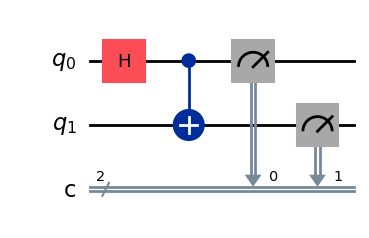

In [2]:
# [EN]: Build a Bell-state circuit to validate entanglement behavior in a controlled sandbox. | 
# [ES]: Construir un circuito de estado Bell para validar el comportamiento de entrelazamiento en un sandbox controlado.
bell_circuit = QuantumCircuit(2, 2)

# [EN]: Put qubit 0 into superposition. |
# [ES]: Llevar el qubit 0 a superposicion.
bell_circuit.h(0)

# [EN]: Correlate qubit 1 with qubit 0 to create entanglement. | 
# [ES]: Correlacionar el qubit 1 con el qubit 0 para crear entrelazamiento.
bell_circuit.cx(0, 1)

# [EN]: Measure both qubits for simulator sampling. | 
# [ES]: Medir ambos qubits para el muestreo del simulador.
bell_circuit.measure([0, 1], [0, 1])

bell_circuit.draw("mpl")


## 4. Validate the Ideal State with Statevector


In [3]:
# [EN]: Rebuild the circuit without measurements to inspect the exact theoretical state. |
# [ES]: Reconstruir el circuito sin mediciones para inspeccionar el estado teorico exacto.
bell_reference = QuantumCircuit(2)
bell_reference.h(0)
bell_reference.cx(0, 1)

# [EN]: Statevector is the fastest checkpoint for validating amplitudes before sampling noise is introduced. | 
# [ES]: Statevector es el punto de control mas rapido para validar amplitudes antes de introducir ruido de muestreo.
ideal_state = Statevector.from_instruction(bell_reference)

print("Ideal statevector:", ideal_state)
print("Ideal probabilities:", ideal_state.probabilities_dict())


Ideal statevector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Ideal probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


## 5. Run AerSimulator


In [4]:
# [EN]: Configure the simulator used for iterative backend testing. |
#  [ES]: Configurar el simulador usado para pruebas iterativas de backend.
simulator = AerSimulator()
shots = 2048

# [EN]: In data engineering terms, shots behave like batch size or partition count: they control sampling granularity, runtime, and statistical confidence during benchmarking. | [ES]: En terminos de ingenieria de datos, los shots funcionan como el tamano de lote o el numero de particiones: controlan la granularidad del muestreo, el tiempo de ejecucion y la confianza estadistica durante el benchmarking.
# [EN]: This sandbox uses AerSimulator settings as a fast performance harness before scaling to larger circuits or hardware backends. | [ES]: Este sandbox usa la configuracion de AerSimulator como un arnes rapido de rendimiento antes de escalar a circuitos mas grandes o backends de hardware.

# [EN]: Transpile for the selected backend to align the circuit with simulator capabilities. | [ES]: Transpilar para el backend seleccionado y alinear el circuito con las capacidades del simulador.
compiled_circuit = transpile(bell_circuit, simulator)

# [EN]: Execute the sampled run. | [ES]: Ejecutar la corrida con muestreo.
job = simulator.run(compiled_circuit, shots=shots)
result = job.result()
counts = result.get_counts()

print("Backend name:", simulator.configuration().backend_name)
print("Shots:", shots)
print("Compiled depth:", compiled_circuit.depth())
print("Measurement counts:", counts)


Backend name: aer_simulator
Shots: 2048
Compiled depth: 3
Measurement counts: {'00': 1037, '11': 1011}


## 6. Visual Verification


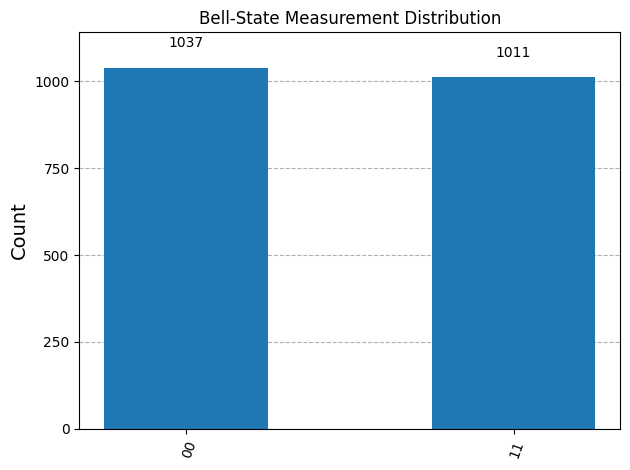

In [9]:
# [EN]: The histogram is the quickest verification layer for confirming entanglement correlation after execution. | [ES]: El histograma es la capa de verificacion mas rapida para confirmar la correlacion del entrelazamiento despues de la ejecucion.
# [EN]: For a Bell state, the expected outcome is a near 50/50 distribution between |00> and |11>, with little or no weight on |01> and |10>. | [ES]: Para un estado Bell, el resultado esperado es una distribucion cercana a 50/50 entre |00> y |11>, con poco o ningun peso en |01> y |10>.
# [EN]: This makes the chart a practical debugging artifact for validating circuit intent, simulator behavior, and regression checks. | [ES]: Esto convierte la grafica en un artefacto practico de depuracion para validar la intencion del circuito, el comportamiento del simulador y las pruebas de regresion.
plot_histogram(counts, title="Bell-State Measurement Distribution")
plt.show()


In [7]:
%matplotlib inline

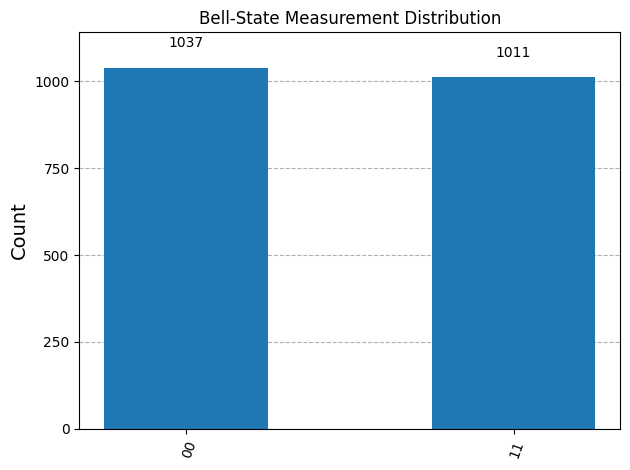

In [8]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

counts = {'00': 1037, '11': 1011}

fig = plot_histogram(counts, title="Bell-State Measurement Distribution")
plt.show(block=True)

## Next Sandbox Iterations

**EN:** Extend this notebook by increasing qubit count, comparing transpilation strategies, or swapping to noisy simulator and runtime backends for performance and fidelity benchmarking.

**ES:** Extiende este notebook aumentando el numero de qubits, comparando estrategias de transpilacion o cambiando a simuladores con ruido y backends de runtime para benchmarking de rendimiento y fidelidad.
